# This notebook can be used to determine the appropriate outer masking parameters for the modeling

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from lenstronomy.Util import mask_util, util

def create_central_mask(kwargs_data, x_coords, y_coords,
                        lens_center_x, lens_center_y,
                        r_outer=4.0,
                        dx_outer=0.0, dy_outer=0.0,
                        use_center_mask=False,
                        dx_center=0.2, dy_center=0.1,
                        a_center=0.6, b_center=0.6, phi_center=0.0,
                        plot=True):
    """
    Create a central mask before modeling.

    Parameters
    ----------
    kwargs_data : dict
        Dictionary containing "image_data".
    x_coords, y_coords : array
        Coordinate grids (pixel coordinates).
    lens_center_x, lens_center_y : float
        Lens center coordinates (RA/DEC in arcseconds).
    r_outer : float
        Radius of the outer circular mask (arcsec).
    dx_outer, dy_outer : float
        Offsets for the outer mask.
    use_center_mask : bool
        Whether to apply an additional central ellipse mask.
    dx_center, dy_center : float
        Offsets for the central ellipse mask.
    a_center, b_center : float
        Semi-major and semi-minor axes of the central mask.
    phi_center : float
        Rotation angle (radians).
    plot : bool
        Whether to plot the results.

    Returns
    -------
    mask_img : 2D array
        Final mask array (1 = keep, 0 = masked).
    image_masked : 2D array
        Log-scaled image after masking.
    """

    num_pix = len(kwargs_data["image_data"])

    # Outer circular mask
    mask_outer = mask_util.mask_center_2d(
        lens_center_x + dx_outer,
        lens_center_y + dy_outer,
        r_outer,
        util.image2array(x_coords),
        util.image2array(y_coords),
    )
    mask = 1 - mask_outer

    # Optional central elliptical mask
    if use_center_mask:
        mask_center = mask_util.mask_ellipse(
            util.image2array(x_coords),
            util.image2array(y_coords),
            lens_center_x + dx_center,
            lens_center_y + dy_center,
            a_center,
            b_center,
            phi_center,
        )
        mask *= (1 - mask_center)

    # Ensure binary mask
    mask[mask >= 1] = 1
    mask[mask < 0] = 0

    # Reshape to image grid
    mask_img = mask.reshape(num_pix, num_pix)

    # Apply to image
    image_masked = np.log10(kwargs_data["image_data"] * mask_img)

    if plot:
        fig, axs = plt.subplots(1, 2, figsize=(15, 10))
        axs[0].imshow(mask_img, origin="lower")
        axs[0].set_title("MASKING")

        axs[1].imshow(image_masked, origin="lower", cmap="cubehelix")
        axs[1].set_title("IMAGE AFTER MASKING")
        plt.show()

    return mask_img, image_masked

# F160W

In [9]:
from astropy.io import fits
from lenstronomy.Data.pixel_grid import PixelGrid

system_name = 'J1620+1203'

# Open the FITS file and extract the header
filename = f'../cutout_data/{system_name}/F160W/{system_name}_F160W_cutout.fits'

with fits.open(filename) as hdul:
    header = hdul[0].header
    image_data = hdul[0].data 

# read out matrix elements and convert them in units of arc seconds
CD1_1 = header['CD1_1'] * 3600  # change in arc sec per pixel d(ra)/dx
CD1_2 = header['CD1_2'] * 3600
CD2_1 = header['CD2_1'] * 3600
CD2_2 = header['CD2_2'] * 3600

# generate pixel-to-coordinate transform matrix and its inverse
pix2coord_transform_undistorted = np.array([[CD1_1, CD1_2], [CD2_1, CD2_2]])
det = CD1_1*CD2_2 - CD1_2*CD2_1
coord2pix_transform_undistorted = np.array([[CD2_2, -CD1_2], [-CD2_1, CD1_1]])/det

# as an example, we set the coordinate zero point in the center of the image and compute 
# the coordinate at the pixel (0,0) at the edge of the image

# read out pixel size of image
nx = header.get('NAXIS1')
ny = header.get('NAXIS2')
x_c = int(nx / 2)
y_c = int(ny / 2)

# compute RA/DEC relative shift between the edge and the center of the image
dra, ddec = pix2coord_transform_undistorted.dot(np.array([x_c, y_c]))
# set edge of the image such that the center has RA/DEC = (0,0)
ra_at_xy_0, dec_at_xy_0 = -dra, -ddec

# import the PixelGrid() class #

deltaPix = 0.08  # size of IR pixel in angular coordinates #

# setup the keyword arguments to create the Data() class #
transform_pix2angle = np.array([[1, 0], [0, 1]]) * deltaPix  # linear translation matrix of a shift in pixel in a shift in coordinates
kwargs_pixel = {'nx': nx, 'ny': ny,  # number of pixels per axis
                'ra_at_xy_0': ra_at_xy_0,  # RA at pixel (0,0)
                'dec_at_xy_0': dec_at_xy_0,  # DEC at pixel (0,0)
                'transform_pix2angle': transform_pix2angle} 
pixel_grid = PixelGrid(**kwargs_pixel)
# return the list of pixel coordinates #
x_coords, y_coords = pixel_grid.pixel_coordinates

# set up data class
kwargs_data3 = {'image_data': image_data,
               'background_rms': header['BACK_RMS'],
               'exposure_time': header['EXPTIME'],
               'ra_at_xy_0': ra_at_xy_0,  
               'dec_at_xy_0': dec_at_xy_0,
               'transform_pix2angle': transform_pix2angle} 

/tmp/ipykernel_808498/3122425814.py:80: RuntimeWarning: divide by zero encountered in log10
  image_masked = np.log10(kwargs_data["image_data"] * mask_img)


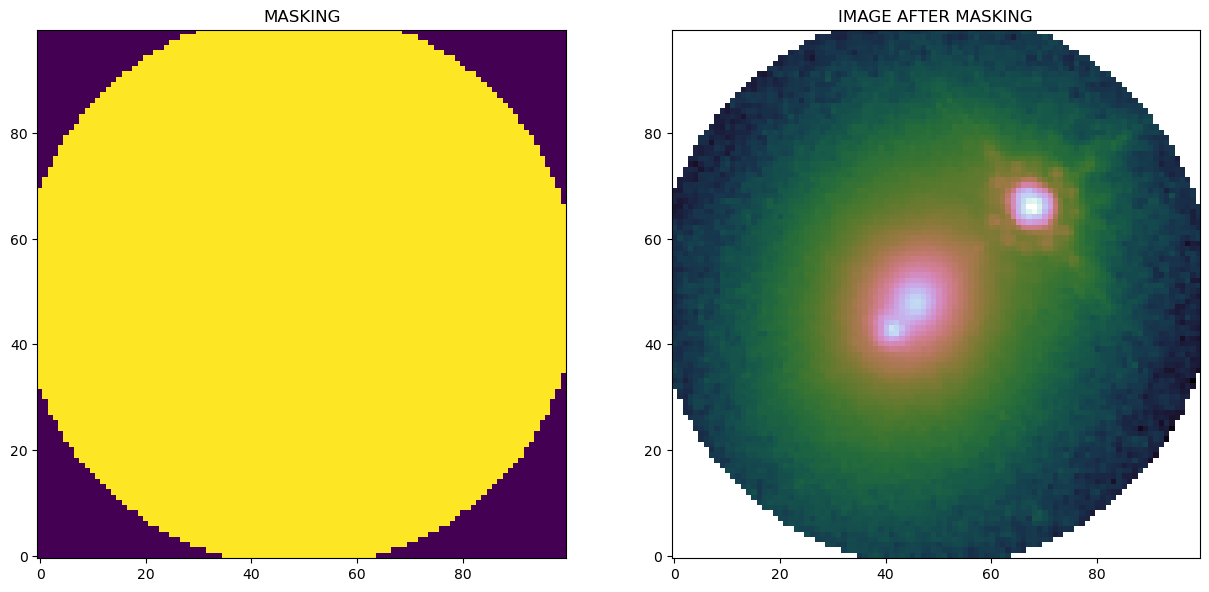

In [10]:
r1 = 4.2
# convert pixel coordinates to angular coordinates
lens_center_pix_x = 44
lens_center_pix_y = 46

# transform to angular coordinates
lens_center_x, lens_center_y = pixel_grid.map_pix2coord(lens_center_pix_x, lens_center_pix_y)

dx_outer = 0.4
dy_outer = 0.35

mask_data3, _ = create_central_mask(kwargs_data3, x_coords, y_coords, lens_center_x, lens_center_y,
                                   r1, dx_outer, dy_outer)

# F814W

In [4]:
# Open the FITS file and extract the header
filename = f'../joint_modeling/{system_name}/{system_name}_F814W_cutout.fits'

with fits.open(filename) as hdul:
    header = hdul[0].header
    image_data = hdul[0].data 

# read out matrix elements and convert them in units of arc seconds
CD1_1 = header['CD1_1'] * 3600  # change in arc sec per pixel d(ra)/dx
CD1_2 = header['CD1_2'] * 3600
CD2_1 = header['CD2_1'] * 3600
CD2_2 = header['CD2_2'] * 3600

# generate pixel-to-coordinate transform matrix and its inverse
pix2coord_transform_undistorted = np.array([[CD1_1, CD1_2], [CD2_1, CD2_2]])
det = CD1_1*CD2_2 - CD1_2*CD2_1
coord2pix_transform_undistorted = np.array([[CD2_2, -CD1_2], [-CD2_1, CD1_1]])/det

# as an example, we set the coordinate zero point in the center of the image and compute 
# the coordinate at the pixel (0,0) at the edge of the image

# read out pixel size of image
nx = header.get('NAXIS1')
ny = header.get('NAXIS2')
x_c = int(nx / 2)
y_c = int(ny / 2)

# compute RA/DEC relative shift between the edge and the center of the image
dra, ddec = pix2coord_transform_undistorted.dot(np.array([x_c, y_c]))
# set edge of the image such that the center has RA/DEC = (0,0)
ra_at_xy_0, dec_at_xy_0 = -dra, -ddec

deltaPix = 0.04  # size of UVIS pixel in angular coordinates #

# setup the keyword arguments to create the Data() class #
transform_pix2angle = np.array([[1, 0], [0, 1]]) * deltaPix  # linear translation matrix of a shift in pixel in a shift in coordinates
kwargs_pixel = {'nx': nx, 'ny': ny,  # number of pixels per axis
                'ra_at_xy_0': ra_at_xy_0,  # RA at pixel (0,0)
                'dec_at_xy_0': dec_at_xy_0,  # DEC at pixel (0,0)
                'transform_pix2angle': transform_pix2angle} 
pixel_grid = PixelGrid(**kwargs_pixel)
# return the list of pixel coordinates #
x_coords, y_coords = pixel_grid.pixel_coordinates

# set up data class
kwargs_data1 = {'image_data': image_data,
               'background_rms': header['BACK_RMS'],
               'exposure_time': header['EXPTIME'],
               'ra_at_xy_0': ra_at_xy_0,  
               'dec_at_xy_0': dec_at_xy_0,
               'transform_pix2angle': transform_pix2angle} 


/tmp/ipykernel_85914/3122425814.py:80: RuntimeWarning: divide by zero encountered in log10
  image_masked = np.log10(kwargs_data["image_data"] * mask_img)
/tmp/ipykernel_85914/3122425814.py:80: RuntimeWarning: invalid value encountered in log10
  image_masked = np.log10(kwargs_data["image_data"] * mask_img)


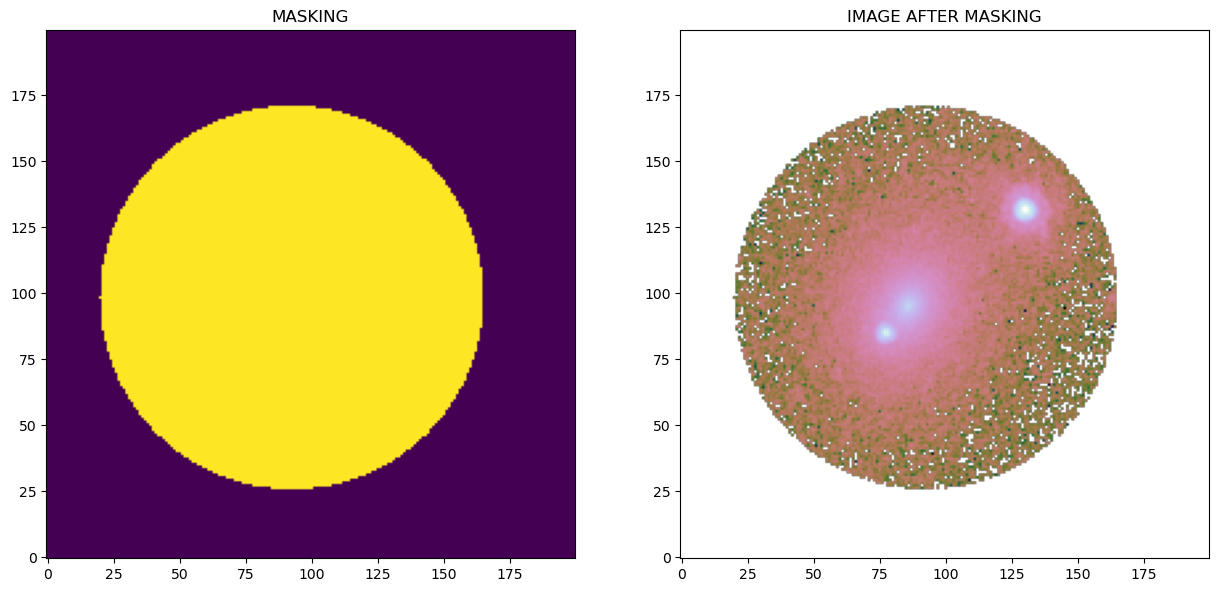

In [12]:
r1_f814w = 2.9
# convert pixel coordinates to angular coordinates
lens_center_pix_x = 85
lens_center_pix_y = 93

# transform to angular coordinates
lens_center_x, lens_center_y = pixel_grid.map_pix2coord(lens_center_pix_x, lens_center_pix_y)

dx_outer_f814w = 0.3
dy_outer_f814w = 0.2

mask_data1, _ = create_central_mask(kwargs_data1, x_coords, y_coords, lens_center_x, lens_center_y,
                                   r1_f814w, dx_outer_f814w, dy_outer_f814w)

# F475X

In [13]:
# Open the FITS file and extract the header
filename = f'../joint_modeling/{system_name}/{system_name}_F475X_cutout.fits'

with fits.open(filename) as hdul:
    header = hdul[0].header
    image_data = hdul[0].data 

# read out matrix elements and convert them in units of arc seconds
CD1_1 = header['CD1_1'] * 3600  # change in arc sec per pixel d(ra)/dx
CD1_2 = header['CD1_2'] * 3600
CD2_1 = header['CD2_1'] * 3600
CD2_2 = header['CD2_2'] * 3600

# generate pixel-to-coordinate transform matrix and its inverse
pix2coord_transform_undistorted = np.array([[CD1_1, CD1_2], [CD2_1, CD2_2]])
det = CD1_1*CD2_2 - CD1_2*CD2_1
coord2pix_transform_undistorted = np.array([[CD2_2, -CD1_2], [-CD2_1, CD1_1]])/det

# as an example, we set the coordinate zero point in the center of the image and compute 
# the coordinate at the pixel (0,0) at the edge of the image

# read out pixel size of image
nx = header.get('NAXIS1')
ny = header.get('NAXIS2')
x_c = int(nx / 2)
y_c = int(ny / 2)

# compute RA/DEC relative shift between the edge and the center of the image
dra, ddec = pix2coord_transform_undistorted.dot(np.array([x_c, y_c]))
# set edge of the image such that the center has RA/DEC = (0,0)
ra_at_xy_0, dec_at_xy_0 = -dra, -ddec

# import the PixelGrid() class #

deltaPix = 0.04  # size of UVIS pixel in angular coordinates #

# setup the keyword arguments to create the Data() class #
transform_pix2angle = np.array([[1, 0], [0, 1]]) * deltaPix  # linear translation matrix of a shift in pixel in a shift in coordinates
kwargs_pixel = {'nx': nx, 'ny': ny,  # number of pixels per axis
                'ra_at_xy_0': ra_at_xy_0,  # RA at pixel (0,0)
                'dec_at_xy_0': dec_at_xy_0,  # DEC at pixel (0,0)
                'transform_pix2angle': transform_pix2angle} 
pixel_grid = PixelGrid(**kwargs_pixel)
# return the list of pixel coordinates #
x_coords, y_coords = pixel_grid.pixel_coordinates

# set up data class
kwargs_data2 = {'image_data': image_data,
               'background_rms': header['BACK_RMS'],
               'exposure_time': header['EXPTIME'],
               'ra_at_xy_0': ra_at_xy_0,  
               'dec_at_xy_0': dec_at_xy_0,
               'transform_pix2angle': transform_pix2angle} 

/tmp/ipykernel_85914/3122425814.py:80: RuntimeWarning: divide by zero encountered in log10
  image_masked = np.log10(kwargs_data["image_data"] * mask_img)
/tmp/ipykernel_85914/3122425814.py:80: RuntimeWarning: invalid value encountered in log10
  image_masked = np.log10(kwargs_data["image_data"] * mask_img)


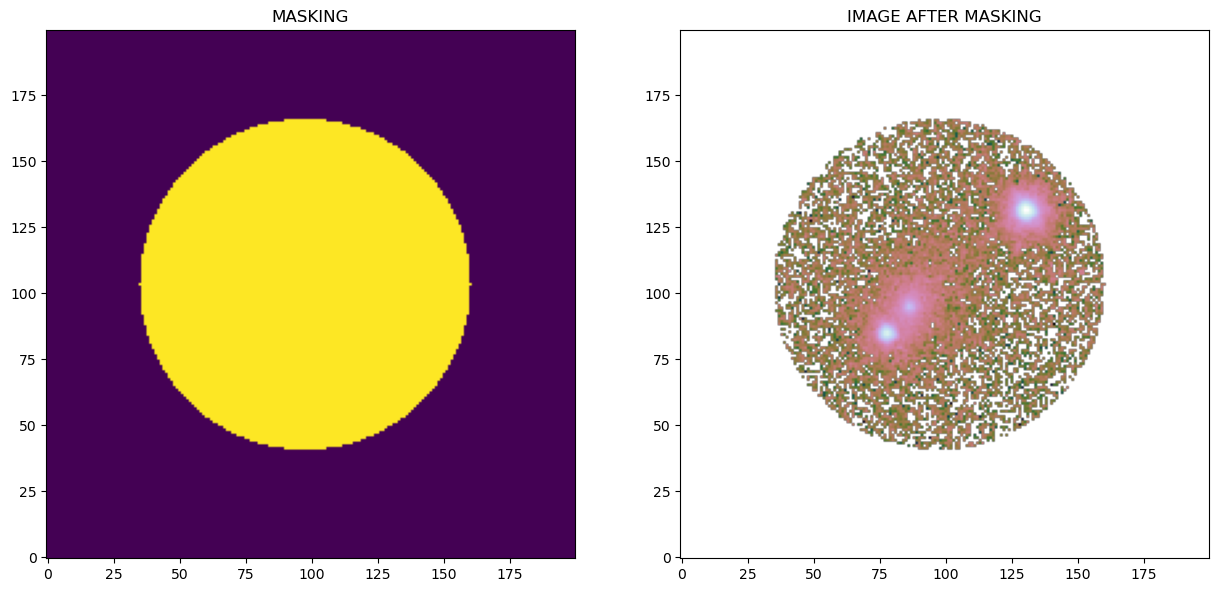

In [18]:
r1_f475x = 2.5
# convert pixel coordinates to angular coordinates
lens_center_pix_x = 85
lens_center_pix_y = 93

# transform to angular coordinates
lens_center_x, lens_center_y = pixel_grid.map_pix2coord(lens_center_pix_x, lens_center_pix_y)

dx_outer_f475x = 0.5
dy_outer_f475x = 0.4

mask_data2, _ = create_central_mask(kwargs_data2, x_coords, y_coords, lens_center_x, lens_center_y,
                                   r1_f475x, dx_outer_f475x, dy_outer_f475x)